#FRAMEWORK

## Análise Epidemiológica — Município de Araranguá/SC

* **Dataset Escolhido:** SIM (Sistema de Informação sobre Mortalidade)
* **Link do Dataset:** [https://apidadosabertos.saude.gov.br/vigilancia-e-meio-ambiente/sistema-de-informacao-sobre-mortalidade](https://apidadosabertos.saude.gov.br/vigilancia-e-meio-ambiente/sistema-de-informacao-sobre-mortalidade)

In [ ]:
import pandas as pd
import numpy as np
import requests
import io
from google.colab import userdata

api_token = userdata.get('API_KEY')

In [ ]:
url_base = "https://apidadosabertos.saude.gov.br/vigilancia-e-meio-ambiente/sistema-de-informacao-sobre-mortalidade"
registros, offset = [], 0

while True:
    try:
        lote = requests.get(url_base, params={'limit': 1000, 'offset': offset}, headers={'accept': 'application/json'}).json().get('sim', [])
        if not lote: break

        # Captura e junta todas as mortes de Araranguá
        registros.extend([r for r in lote if '420140' in str(r.get('codmunres', ''))])
        offset += 1000
    except:
        break # Prevenção contra instabilidade na rede

df_ararangua_bruto = pd.DataFrame(registros)
print(f"Extração completa concluída! Total de registros: {df_ararangua_bruto.shape[0]}")

Extração completa concluída! Total de registros: 285


In [ ]:
# Cria a variável df_ararangua a partir dos dados brutos
df_ararangua = df_ararangua_bruto.copy()

# Agora sim, salva o arquivo CSV usando a nova variável
df_ararangua.to_csv('sim_ararangua_historico.csv', index=False, encoding='utf-8-sig')
print("Arquivo 'sim_ararangua_historico.csv' salvo com sucesso!")

Arquivo 'sim_ararangua_historico.csv' salvo com sucesso!


In [ ]:
from google.colab import files

# Salva o arquivo localmente no Colab
df_ararangua.to_csv('dados_mortalidade_ararangua.csv', index=False, encoding='utf-8-sig')

# Faz o download automático
files.download('dados_mortalidade_ararangua.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Informações Gerais do Dataset
print(df_ararangua.info())

# Valores Ausentes por Coluna (Top 10)
print(df_ararangua.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 86 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   racacor     280 non-null    object
 1   dtconinv    14 non-null     object
 2   gravidez    3 non-null      object
 3   peso        3 non-null      object
 4   fonteinv    14 non-null     object
 5   dtrecebim   285 non-null    object
 6   idademae    3 non-null      object
 7   dtrecoriga  285 non-null    object
 8   atestante   275 non-null    object
 9   comunsvoim  19 non-null     object
 10  horaobito   283 non-null    object
 11  contador    285 non-null    object
 12  linhaii     139 non-null    object
 13  altcausa    3 non-null      object
 14  causabas    285 non-null    object
 15  versaosist  285 non-null    object
 16  idade       285 non-null    object
 17  natural     284 non-null    object
 18  morteparto  3 non-null      object
 19  ocup        239 non-null    object
 20  acidtrab  

In [ ]:
# Remover colunas que estão 100% vazias
df_limpo = df_ararangua.dropna(axis=1, how='all').copy()

# Tratar datas (SIM costuma usar o formato DDMMAAAA ou strings de data)
# Converter as colunas de data mais comuns do SIM
colunas_data = ['dtobito', 'dtnasc']

for col in colunas_data:
    if col in df_limpo.columns:
        # Força a conversão para string e depois para datetime, lidando com erros
        df_limpo[col] = pd.to_datetime(df_limpo[col], errors='coerce', format='%d%m%Y')

# Preencher valores nulos textuais críticos com 'Ignorado'
colunas_criticas = ['sexo', 'racacor', 'estciv', 'causabas']
for col in colunas_criticas:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna('Ignorado').astype(str).str.strip()

print(f"Dataset limpo! Formato atual: {df_limpo.shape}")

Dataset limpo! Formato atual: (285, 81)


In [ ]:
# Criando uma cópia para preservar os teus dados brutos originais
df_limpo = df_ararangua.copy()

# Dicionários de tradução
mapa_sexo = {'1': 'Masculino', '2': 'Feminino', '0': 'Ignorado', 'I': 'Ignorado'}
mapa_raca = {'1': 'Branca', '2': 'Preta', '3': 'Amarela', '4': 'Parda', '5': 'Indígena'}
mapa_est_civil = {'1': 'Solteiro(a)', '2': 'Casado(a)', '3': 'Viúvo(a)', '4': 'Divorciado(a)', '5': 'União Estável', '9': 'Ignorado'}

mapa_cid_capitulos = {
    'A': 'Doenças Infecciosas e Parasitárias (Cap. I)', 'B': 'Doenças Infecciosas e Parasitárias (Cap. I)',
    'C': 'Neoplasias (Tumores) (Cap. II)', 'D': 'Neoplasias / Doenças do Sangue (Cap. II/III)',
    'E': 'Doenças Endócrinas, Nutricionais e Metabólicas (Cap. IV)', 'F': 'Transtornos Mentais e Comportamentais (Cap. V)',
    'G': 'Doenças do Sistema Nervoso (Cap. VI)', 'H': 'Doenças do Olho / Ouvido (Cap. VII/VIII)',
    'I': 'Doenças do Sistema Circulatório (Cap. IX)', 'J': 'Doenças do Sistema Respiratório (Cap. X)',
    'K': 'Doenças do Sistema Digestivo (Cap. XI)', 'L': 'Doenças da Pele e Tecido Subcutâneo (Cap. XII)',
    'M': 'Doenças do Sistema Osteomuscular (Cap. XIII)', 'N': 'Doenças do Sistema Geniturinário (Cap. XIV)',
    'O': 'Gravidez, Parto e Puerpério (Cap. XV)', 'P': 'Afecções Originadas no Período Perinatal (Cap. XVI)',
    'Q': 'Malformações Congênitas e Anomalias (Cap. XVII)', 'R': 'Sintomas e Achados Anormais (Cap. XVIII)',
    'V': 'Causas Externas (Acidentes/Violência) (Cap. XX)', 'W': 'Causas Externas (Acidentes/Violência) (Cap. XX)',
    'X': 'Causas Externas (Acidentes/Violência) (Cap. XX)', 'Y': 'Causas Externas (Acidentes/Violência) (Cap. XX)',
    'Z': 'Fatores que Influenciam a Saúde (Cap. XXI)', 'U': 'Fins Especiais - ex: COVID-19 (Cap. XXII)'
}

# Aplicando os mapeamentos direto nas colunas
df_limpo['sexo_desc'] = df_limpo['sexo'].astype(str).str.strip().map(mapa_sexo).fillna('Ignorado')
df_limpo['racacor_desc'] = df_limpo['racacor'].astype(str).str.strip().map(mapa_raca).fillna('Ignorado')
df_limpo['estado_civil_desc'] = df_limpo['estciv'].astype(str).str.strip().map(mapa_est_civil).fillna('Ignorado')

# Extraindo a primeira letra do CID para traduzir pelo dicionário
df_limpo['letra_cid'] = df_limpo['causabas'].astype(str).str.strip().str.get(0).str.upper()
df_limpo['causa_morte_desc'] = df_limpo['letra_cid'].map(mapa_cid_capitulos).fillna('Ignorado / Outras')

# Salvando a versão limpa final
df_limpo.to_csv('sim_ararangua_limpo_traduzido.csv', index=False, encoding='utf-8-sig')
print("Traduções concluídas com sucesso!")

Traduções concluídas com sucesso!


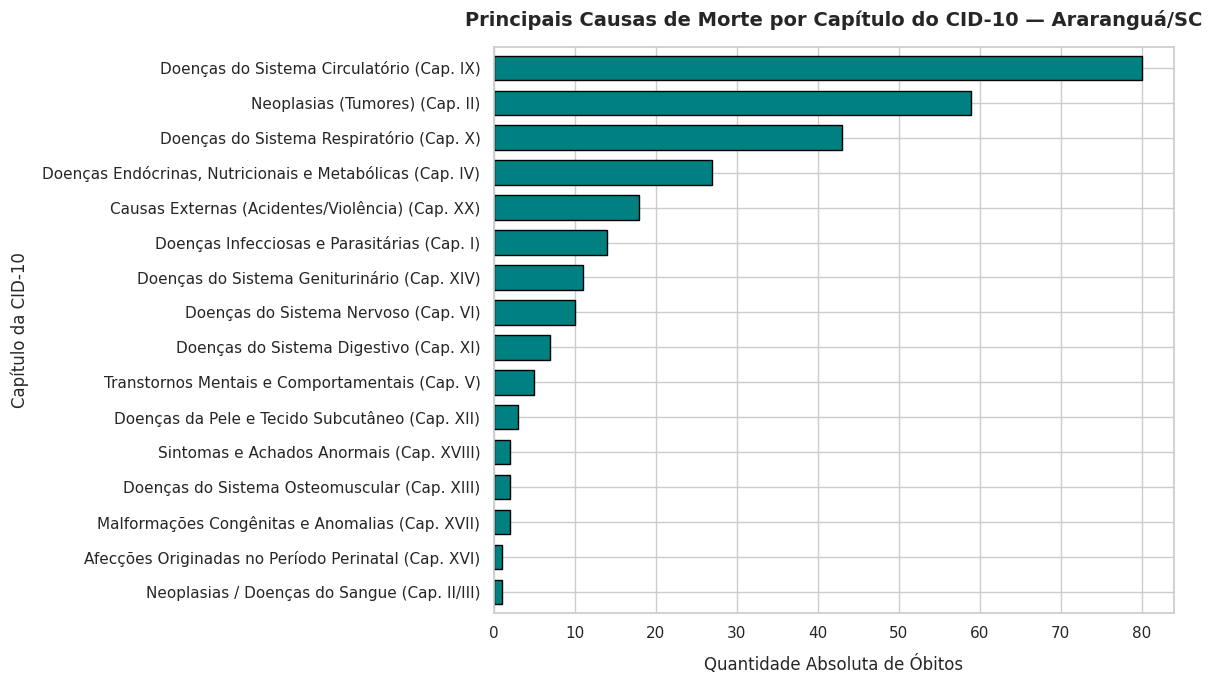

In [ ]:
# Importando as bibliotecas necessárias para o gráfico
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Criando o gráfico de barras horizontais ordenadas (do maior para o menor)
df_limpo['causa_morte_desc'].value_counts().plot(kind='barh', color='teal', edgecolor='black', width=0.7).invert_yaxis()

# Títulos do gráfico
plt.title('Principais Causas de Morte por Capítulo do CID-10 — Araranguá/SC', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Quantidade Absoluta de Óbitos', fontsize=12, labelpad=10)
plt.ylabel('Capítulo da CID-10', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('maiores_causas_morte_ararangua.png', dpi=300)
plt.show()

In [ ]:
# Salva localmente no ambiente do Colab
df_limpo.to_csv('dados_mortalidade_ararangua_tratado.csv', index=False, encoding='utf-8-sig')
print("Arquivo final 'dados_mortalidade_ararangua_tratado.csv' exportado com sucesso!")

# Baixa automaticamente de novo:
files.download('dados_mortalidade_ararangua_tratado.csv')

Arquivo final 'dados_mortalidade_ararangua_tratado.csv' exportado com sucesso!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>